# 🏆 HAM10000 — Ensemble Meta-Learner (Stacking)

Об'єднуємо предікти трьох моделей в один фінальний класифікатор:

| Модель | Backbone | Input | Predictions |
|--------|----------|-------|-------------|
| v4 | EfficientNetV2B2 | Raw RGB | `preds_*_v4.npy` |
| v5 | ConvNeXtTiny | Segmented image | `preds_*_v5.npy` |
| v6 | DenseNet121 | 4-ch RGB+Mask | `preds_*_v6.npy` |

**Meta-learner:** маленька нейронка, яка приймає конкатенацію ймовірностей (21 вхід = 3×7) і видає фінальний клас.

## Part 1 — Імпорти

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


In [ ]:
try:
    import xgboost as xgb
    print(f'XGBoost: {xgb.__version__}')
except ImportError:
    !pip install xgboost -q
    import xgboost as xgb
    print(f'XGBoost installed: {xgb.__version__}')

XGBoost: 3.2.0


## Part 2 — Завантаження предіктів

⚠️ **Зміни шляхи** під свою структуру на Google Drive!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ===== ШЛЯХИ — ЗМІНИ ПІД СЕБЕ! =====
V4_DIR = '/content/drive/MyDrive/HAM10000_v4/'
V5_DIR = '/content/drive/MyDrive/HAM10000_v5_seg/'
V6_DIR = '/content/drive/MyDrive/HAM10000_v6_4ch/'

# Val predictions (для тренування meta-learner)
preds_val_v4 = np.load(os.path.join(V4_DIR, 'preds_val_v4.npy'))
preds_val_v5 = np.load(os.path.join(V5_DIR, 'preds_val_v5.npy'))
preds_val_v6 = np.load(os.path.join(V6_DIR, 'preds_val_v6.npy'))

# Test predictions (для фінальної оцінки)
preds_test_v4 = np.load(os.path.join(V4_DIR, 'preds_test_v4.npy'))
preds_test_v5 = np.load(os.path.join(V5_DIR, 'preds_test_v5.npy'))
preds_test_v6 = np.load(os.path.join(V6_DIR, 'preds_test_v6.npy'))

# Labels
y_val  = np.load(os.path.join(V5_DIR, 'y_val_v5.npy'))
y_test = np.load(os.path.join(V5_DIR, 'y_test_v5.npy'))

print(f'Val predictions:  v4={preds_val_v4.shape}, v5={preds_val_v5.shape}, v6={preds_val_v6.shape}')
print(f'Test predictions: v4={preds_test_v4.shape}, v5={preds_test_v5.shape}, v6={preds_test_v6.shape}')
print(f'Val labels: {y_val.shape}, Test labels: {y_test.shape}')

# Verify shapes match
assert preds_val_v4.shape[0] == preds_val_v5.shape[0] == preds_val_v6.shape[0] == y_val.shape[0]
assert preds_test_v4.shape[0] == preds_test_v5.shape[0] == preds_test_v6.shape[0] == y_test.shape[0]
print('\nAll shapes match!')

Mounted at /content/drive
Val predictions:  v4=(1525, 7), v5=(1525, 7), v6=(1525, 7)
Test predictions: v4=(1527, 7), v5=(1527, 7), v6=(1527, 7)
Val labels: (1525,), Test labels: (1527,)

All shapes match!


In [ ]:
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = len(classes)
LABEL_NAMES = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions'
}

# Concat features
X_val  = np.concatenate([preds_val_v4, preds_val_v5, preds_val_v6], axis=1)   # (N, 21)
X_test = np.concatenate([preds_test_v4, preds_test_v5, preds_test_v6], axis=1) # (N, 21)

print(f'Meta features — Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Features: 7 (v4) + 7 (v5) + 7 (v6) = {X_val.shape[1]}')

Meta features — Val: (1525, 21), Test: (1527, 21)
Features: 7 (v4) + 7 (v5) + 7 (v6) = 21


## Part 3 — Базові результати кожної моделі окремо

Спочатку подивимось метрики кожної моделі окремо, щоб потім порівняти з ensemble.

In [ ]:
print('=' * 70)
print(f'{" INDIVIDUAL MODEL RESULTS ON TEST SET ":=^70}')
print('=' * 70)

results = {}
for name, preds in [('v4 EfficientNetV2B2', preds_test_v4),
                     ('v5 ConvNeXtTiny+Seg', preds_test_v5),
                     ('v6 DenseNet121 4ch', preds_test_v6)]:
    y_pred = np.argmax(preds, axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    f1w = f1_score(y_test, y_pred, average='weighted')
    y_oh = np.eye(NUM_CLASSES)[y_test]
    auc_m = roc_auc_score(y_oh, preds, average='macro', multi_class='ovr')
    results[name] = {'acc': acc, 'f1_macro': f1m, 'f1_weighted': f1w, 'auc': auc_m}
    print(f'\n{name}:')
    print(f'  Accuracy:    {acc:.4f}')
    print(f'  F1 (macro):  {f1m:.4f}')
    print(f'  F1 (weight): {f1w:.4f}')
    print(f'  AUC (macro): {auc_m:.4f}')

# Simple average ensemble (baseline)
preds_avg = (preds_test_v4 + preds_test_v5 + preds_test_v6) / 3
y_pred_avg = np.argmax(preds_avg, axis=1)
acc_avg = accuracy_score(y_test, y_pred_avg)
f1m_avg = f1_score(y_test, y_pred_avg, average='macro')
f1w_avg = f1_score(y_test, y_pred_avg, average='weighted')
auc_avg = roc_auc_score(np.eye(NUM_CLASSES)[y_test], preds_avg, average='macro', multi_class='ovr')
results['Simple Average'] = {'acc': acc_avg, 'f1_macro': f1m_avg, 'f1_weighted': f1w_avg, 'auc': auc_avg}

print(f'\n{"Simple Average Ensemble":}')
print(f'  Accuracy:    {acc_avg:.4f}')
print(f'  F1 (macro):  {f1m_avg:.4f}')
print(f'  F1 (weight): {f1w_avg:.4f}')
print(f'  AUC (macro): {auc_avg:.4f}')

================ INDIVIDUAL MODEL RESULTS ON TEST SET ================

v4 EfficientNetV2B2:
  Accuracy:    0.8219
  F1 (macro):  0.6993
  F1 (weight): 0.8237
  AUC (macro): 0.9528

v5 ConvNeXtTiny+Seg:
  Accuracy:    0.8075
  F1 (macro):  0.6808
  F1 (weight): 0.8057
  AUC (macro): 0.9484

v6 DenseNet121 4ch:
  Accuracy:    0.7944
  F1 (macro):  0.6350
  F1 (weight): 0.7913
  AUC (macro): 0.9427

Simple Average Ensemble
  Accuracy:    0.8389
  F1 (macro):  0.7483
  F1 (weight): 0.8350
  AUC (macro): 0.9647


## Part 4 — Аналіз різноманітності моделей

Дивимось наскільки моделі роблять різні помилки — це ключове для ефективності ensemble.

In [ ]:
pred_v4 = np.argmax(preds_test_v4, axis=1)
pred_v5 = np.argmax(preds_test_v5, axis=1)
pred_v6 = np.argmax(preds_test_v6, axis=1)

# Disagreement matrix
pairs = [('v4 vs v5', pred_v4, pred_v5),
         ('v4 vs v6', pred_v4, pred_v6),
         ('v5 vs v6', pred_v5, pred_v6)]

print('Model Disagreement (% samples where predictions differ):')
print('-' * 50)
for name, p1, p2 in pairs:
    disagree = (p1 != p2).mean() * 100
    print(f'  {name}: {disagree:.1f}%')

# Where all agree vs disagree
all_agree = (pred_v4 == pred_v5) & (pred_v5 == pred_v6)
print(f'\nAll 3 models agree: {all_agree.mean()*100:.1f}%')
print(f'At least one disagrees: {(~all_agree).mean()*100:.1f}%')

# Accuracy when all agree vs disagree
acc_agree = accuracy_score(y_test[all_agree], pred_v4[all_agree])
acc_disagree = accuracy_score(y_test[~all_agree], y_pred_avg[~all_agree])
print(f'\nAccuracy when all agree: {acc_agree:.4f}')
print(f'Accuracy when disagree (avg ensemble): {acc_disagree:.4f}')

Model Disagreement (% samples where predictions differ):
--------------------------------------------------
  v4 vs v5: 17.7%
  v4 vs v6: 16.3%
  v5 vs v6: 18.3%

All 3 models agree: 75.3%
At least one disagrees: 24.7%

Accuracy when all agree: 0.9209
Accuracy when disagree (avg ensemble): 0.5889


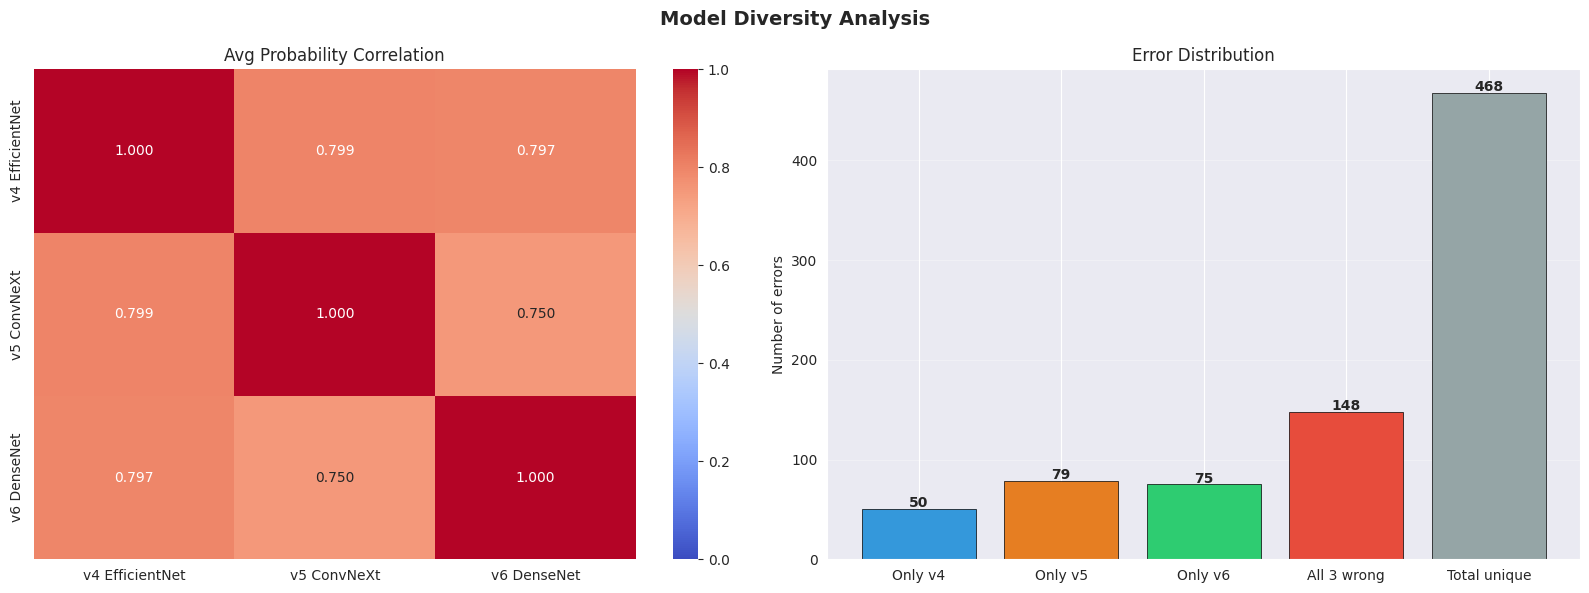


Errors unique to each model:
  v4 only: 50 — ensemble can fix these
  v5 only: 79 — ensemble can fix these
  v6 only: 75 — ensemble can fix these
  All 3 wrong: 148 — ensemble cannot fix these
  Fixable by ensemble: 320/468 (68.4%)


In [ ]:
# Correlation matrix of predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Diversity Analysis', fontsize=14, fontweight='bold')

# Prediction correlation
from scipy.stats import spearmanr
pred_matrix = np.column_stack([pred_v4, pred_v5, pred_v6])
corr = np.corrcoef(pred_matrix.T)
# Use per-class probability correlations instead
corr_probs = np.corrcoef(
    np.concatenate([preds_test_v4, preds_test_v5, preds_test_v6], axis=1).T
)

model_names = [f'v4_{c}' for c in classes] + [f'v5_{c}' for c in classes] + [f'v6_{c}' for c in classes]

# Simplified: average correlation between models
corr_v4_v5 = np.mean([np.corrcoef(preds_test_v4[:, i], preds_test_v5[:, i])[0, 1] for i in range(7)])
corr_v4_v6 = np.mean([np.corrcoef(preds_test_v4[:, i], preds_test_v6[:, i])[0, 1] for i in range(7)])
corr_v5_v6 = np.mean([np.corrcoef(preds_test_v5[:, i], preds_test_v6[:, i])[0, 1] for i in range(7)])

corr_matrix = np.array([
    [1.0, corr_v4_v5, corr_v4_v6],
    [corr_v4_v5, 1.0, corr_v5_v6],
    [corr_v4_v6, corr_v5_v6, 1.0]
])

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0.5,
            xticklabels=['v4 EfficientNet', 'v5 ConvNeXt', 'v6 DenseNet'],
            yticklabels=['v4 EfficientNet', 'v5 ConvNeXt', 'v6 DenseNet'],
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Avg Probability Correlation')

# Error overlap Venn-like
errors_v4 = set(np.where(pred_v4 != y_test)[0])
errors_v5 = set(np.where(pred_v5 != y_test)[0])
errors_v6 = set(np.where(pred_v6 != y_test)[0])

only_v4 = len(errors_v4 - errors_v5 - errors_v6)
only_v5 = len(errors_v5 - errors_v4 - errors_v6)
only_v6 = len(errors_v6 - errors_v4 - errors_v5)
all_err = len(errors_v4 & errors_v5 & errors_v6)
total_err = len(errors_v4 | errors_v5 | errors_v6)

labels_bar = ['Only v4', 'Only v5', 'Only v6', 'All 3 wrong', 'Total unique']
values_bar = [only_v4, only_v5, only_v6, all_err, total_err]
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#95a5a6']

axes[1].bar(labels_bar, values_bar, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(values_bar):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[1].set_title('Error Distribution')
axes[1].set_ylabel('Number of errors')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ensemble_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nErrors unique to each model:')
print(f'  v4 only: {only_v4} — ensemble can fix these')
print(f'  v5 only: {only_v5} — ensemble can fix these')
print(f'  v6 only: {only_v6} — ensemble can fix these')
print(f'  All 3 wrong: {all_err} — ensemble cannot fix these')
print(f'  Fixable by ensemble: {total_err - all_err}/{total_err} ({(total_err-all_err)/total_err*100:.1f}%)')

## Part 5 — Meta-Learner: порівнюємо підходи

Тренуємо кілька meta-learners і обираємо найкращий:
1. **Logistic Regression** — простий baseline
2. **XGBoost** — потужний gradient boosting
3. **Neural Network** — маленька нейронка
4. **Weighted Average** — оптимальні ваги для кожної моделі

In [ ]:
from sklearn.model_selection import StratifiedKFold

# ===== 1. Logistic Regression =====
lr = LogisticRegression(max_iter=1000, C=1.0, multi_class='multinomial', random_state=42)
lr.fit(X_val, y_val)
pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr, average='macro')
auc_lr = roc_auc_score(np.eye(NUM_CLASSES)[y_test], proba_lr, average='macro', multi_class='ovr')
results['Meta: LogReg'] = {'acc': acc_lr, 'f1_macro': f1_lr, 'auc': auc_lr}
print(f'Logistic Regression:  Acc={acc_lr:.4f}  F1={f1_lr:.4f}  AUC={auc_lr:.4f}')

# ===== 2. XGBoost =====
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
)
xgb_model.fit(X_val, y_val, verbose=False)
pred_xgb = xgb_model.predict(X_test)
proba_xgb = xgb_model.predict_proba(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)
f1_xgb = f1_score(y_test, pred_xgb, average='macro')
auc_xgb = roc_auc_score(np.eye(NUM_CLASSES)[y_test], proba_xgb, average='macro', multi_class='ovr')
results['Meta: XGBoost'] = {'acc': acc_xgb, 'f1_macro': f1_xgb, 'auc': auc_xgb}
print(f'XGBoost:              Acc={acc_xgb:.4f}  F1={f1_xgb:.4f}  AUC={auc_xgb:.4f}')

Logistic Regression:  Acc=0.8356  F1=0.7093  AUC=0.9587
XGBoost:              Acc=0.8193  F1=0.7030  AUC=0.9594


In [ ]:
# ===== 3. Neural Network meta-learner =====
def build_meta_nn(input_dim, num_classes):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# Train with cross-validation on val set
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nn_test_preds = []

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_val, y_val)):
    X_tr, X_vl = X_val[tr_idx], X_val[vl_idx]
    y_tr, y_vl = y_val[tr_idx], y_val[vl_idx]

    y_tr_oh = np.eye(NUM_CLASSES)[y_tr]
    y_vl_oh = np.eye(NUM_CLASSES)[y_vl]

    meta_nn = build_meta_nn(X_val.shape[1], NUM_CLASSES)
    meta_nn.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    meta_nn.fit(
        X_tr, y_tr_oh,
        validation_data=(X_vl, y_vl_oh),
        epochs=100,
        batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
        verbose=0,
    )

    pred_fold = meta_nn.predict(X_test, verbose=0)
    nn_test_preds.append(pred_fold)
    val_acc = accuracy_score(y_vl, np.argmax(meta_nn.predict(X_vl, verbose=0), axis=1))
    print(f'  Fold {fold+1}: val_acc={val_acc:.4f}')

# Average across folds
proba_nn = np.mean(nn_test_preds, axis=0)
pred_nn = np.argmax(proba_nn, axis=1)
acc_nn = accuracy_score(y_test, pred_nn)
f1_nn = f1_score(y_test, pred_nn, average='macro')
auc_nn = roc_auc_score(np.eye(NUM_CLASSES)[y_test], proba_nn, average='macro', multi_class='ovr')
results['Meta: Neural Net'] = {'acc': acc_nn, 'f1_macro': f1_nn, 'auc': auc_nn}
print(f'\nNeural Network (5-fold): Acc={acc_nn:.4f}  F1={f1_nn:.4f}  AUC={auc_nn:.4f}')

  Fold 1: val_acc=0.8164
  Fold 2: val_acc=0.8852
  Fold 3: val_acc=0.8721
  Fold 4: val_acc=0.8262
  Fold 5: val_acc=0.8590

Neural Network (5-fold): Acc=0.8278  F1=0.7202  AUC=0.9541


In [ ]:
# ===== 4. Optimized Weighted Average =====
from scipy.optimize import minimize

def neg_f1_weighted(weights):
    w = np.array(weights)
    w = w / w.sum()  # normalize
    preds_w = w[0] * preds_val_v4 + w[1] * preds_val_v5 + w[2] * preds_val_v6
    y_pred_w = np.argmax(preds_w, axis=1)
    return -f1_score(y_val, y_pred_w, average='macro')

# Optimize weights on val set
res = minimize(neg_f1_weighted, x0=[1/3, 1/3, 1/3],
               method='Nelder-Mead',
               bounds=[(0.01, 1), (0.01, 1), (0.01, 1)])

best_weights = np.array(res.x) / np.sum(res.x)
print(f'Optimal weights: v4={best_weights[0]:.3f}, v5={best_weights[1]:.3f}, v6={best_weights[2]:.3f}')

preds_weighted = best_weights[0] * preds_test_v4 + best_weights[1] * preds_test_v5 + best_weights[2] * preds_test_v6
pred_weighted = np.argmax(preds_weighted, axis=1)
acc_w = accuracy_score(y_test, pred_weighted)
f1_w = f1_score(y_test, pred_weighted, average='macro')
auc_w = roc_auc_score(np.eye(NUM_CLASSES)[y_test], preds_weighted, average='macro', multi_class='ovr')
results['Weighted Average'] = {'acc': acc_w, 'f1_macro': f1_w, 'auc': auc_w}
print(f'Weighted Average:     Acc={acc_w:.4f}  F1={f1_w:.4f}  AUC={auc_w:.4f}')

Optimal weights: v4=0.365, v5=0.330, v6=0.305
Weighted Average:     Acc=0.8396  F1=0.7484  AUC=0.9647


## Part 6 — Порівняння всіх підходів

In [ ]:
# Summary table
print('\n' + '=' * 75)
print(f'{" FINAL COMPARISON ":=^75}')
print('=' * 75)
print(f'{"Method":<25s} {"Accuracy":>10s} {"F1 macro":>10s} {"AUC macro":>10s}')
print('-' * 75)

for name, m in sorted(results.items(), key=lambda x: x[1].get('f1_macro', 0)):
    print(f'{name:<25s} {m["acc"]:>10.4f} {m["f1_macro"]:>10.4f} {m.get("auc", 0):>10.4f}')

# Find best
best_method = max(results.items(), key=lambda x: x[1]['f1_macro'])
print(f'\n🏆 Best method: {best_method[0]} (F1 macro = {best_method[1]["f1_macro"]:.4f})')


============================ FINAL COMPARISON =============================
Method                      Accuracy   F1 macro  AUC macro
---------------------------------------------------------------------------
v6 DenseNet121 4ch            0.7944     0.6350     0.9427
v5 ConvNeXtTiny+Seg           0.8075     0.6808     0.9484
v4 EfficientNetV2B2           0.8219     0.6993     0.9528
Meta: XGBoost                 0.8193     0.7030     0.9594
Meta: LogReg                  0.8356     0.7093     0.9587
Meta: Neural Net              0.8258     0.7240     0.9572
Simple Average                0.8389     0.7483     0.9647
Weighted Average              0.8396     0.7484     0.9647

🏆 Best method: Weighted Average (F1 macro = 0.7484)


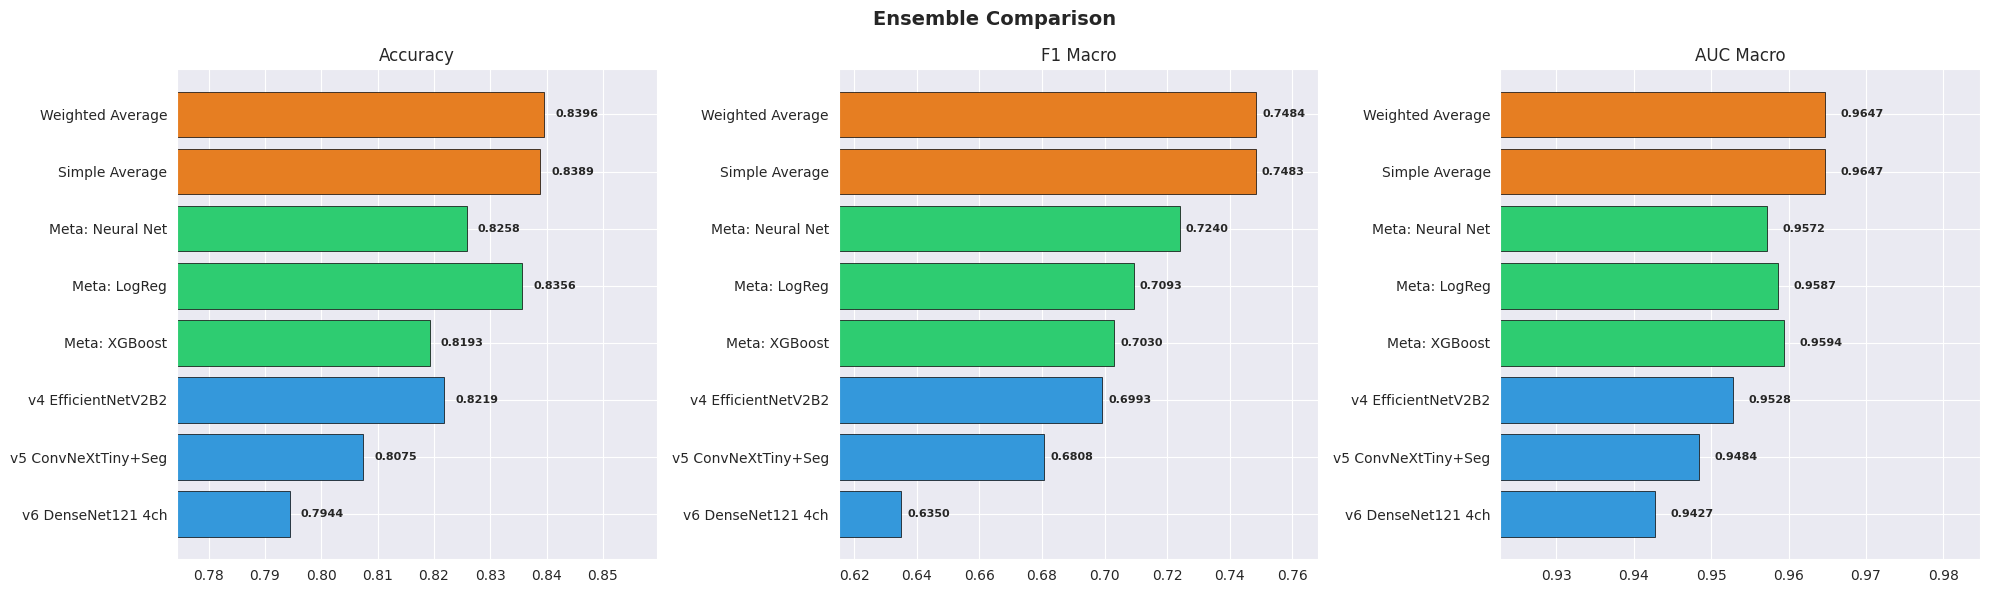

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ensemble Comparison', fontsize=14, fontweight='bold')

methods = list(results.keys())
accs = [results[m]['acc'] for m in methods]
f1s  = [results[m]['f1_macro'] for m in methods]
aucs = [results[m].get('auc', 0) for m in methods]

colors = ['#3498db' if 'v4' in m or 'v5' in m or 'v6' in m else
          '#e67e22' if 'Average' in m or 'Weighted' in m else
          '#2ecc71' for m in methods]

# Sort by f1
order = np.argsort(f1s)
methods_s = [methods[i] for i in order]
f1s_s = [f1s[i] for i in order]
accs_s = [accs[i] for i in order]
aucs_s = [aucs[i] for i in order]
colors_s = [colors[i] for i in order]

axes[0].barh(methods_s, accs_s, color=colors_s, edgecolor='black', linewidth=0.5)
axes[0].set_title('Accuracy')
axes[0].set_xlim(min(accs_s) - 0.02, max(accs_s) + 0.02)
for i, v in enumerate(accs_s):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=8)

axes[1].barh(methods_s, f1s_s, color=colors_s, edgecolor='black', linewidth=0.5)
axes[1].set_title('F1 Macro')
axes[1].set_xlim(min(f1s_s) - 0.02, max(f1s_s) + 0.02)
for i, v in enumerate(f1s_s):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=8)

axes[2].barh(methods_s, aucs_s, color=colors_s, edgecolor='black', linewidth=0.5)
axes[2].set_title('AUC Macro')
axes[2].set_xlim(min(aucs_s) - 0.02, max(aucs_s) + 0.02)
for i, v in enumerate(aucs_s):
    axes[2].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 7 — Детальний аналіз найкращого ensemble

In [ ]:
# Use best method predictions
# Auto-select best
best_name = best_method[0]
print(f'Detailed analysis for: {best_name}')

if 'LogReg' in best_name:
    best_preds = proba_lr
    best_pred_cls = pred_lr
elif 'XGBoost' in best_name:
    best_preds = proba_xgb
    best_pred_cls = pred_xgb
elif 'Neural' in best_name:
    best_preds = proba_nn
    best_pred_cls = pred_nn
elif 'Weighted' in best_name:
    best_preds = preds_weighted
    best_pred_cls = pred_weighted
else:
    best_preds = preds_avg
    best_pred_cls = y_pred_avg

print(f'\n{classification_report(y_test, best_pred_cls, target_names=classes)}')

Detailed analysis for: Weighted Average

              precision    recall  f1-score   support

       akiec       0.63      0.50      0.56        48
         bcc       0.66      0.89      0.76        66
         bkl       0.69      0.70      0.70       172
          df       0.89      0.80      0.84        10
         mel       0.70      0.54      0.61       186
          nv       0.90      0.93      0.92      1016
        vasc       0.92      0.79      0.85        29

    accuracy                           0.84      1527
   macro avg       0.77      0.74      0.75      1527
weighted avg       0.84      0.84      0.84      1527



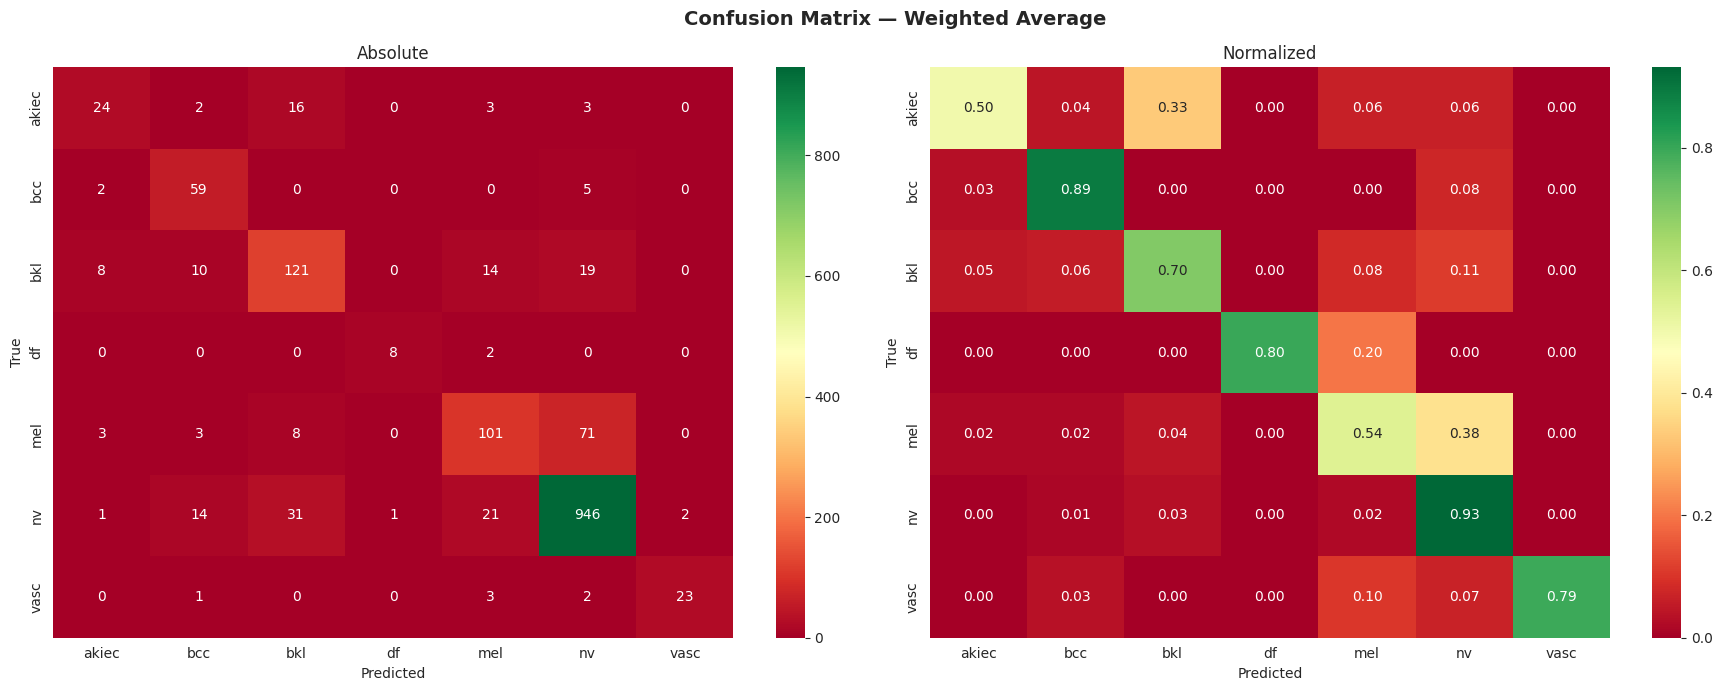

In [ ]:
# Confusion matrix — best ensemble
cm      = confusion_matrix(y_test, best_pred_cls)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Absolute')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Normalized')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

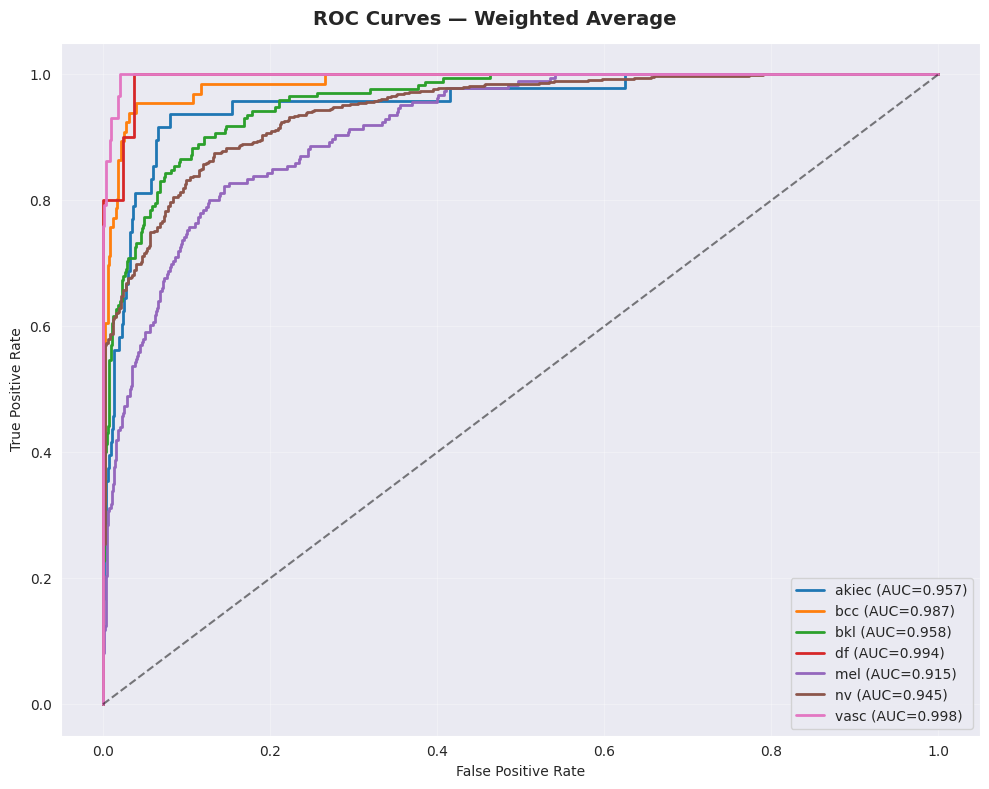

Macro AUC: 0.9647


In [ ]:
# ROC curves — best ensemble
y_true_oh = np.eye(NUM_CLASSES)[y_test]

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f'ROC Curves — {best_name}', fontsize=14, fontweight='bold')

auc_scores = {}
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_oh[:, i], best_preds[:, i])
    auc_val = auc(fpr, tpr)
    auc_scores[cls] = auc_val
    ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ensemble_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

macro_auc = np.mean(list(auc_scores.values()))
print(f'Macro AUC: {macro_auc:.4f}')

## Part 8 — Per-class порівняння: Individual vs Ensemble

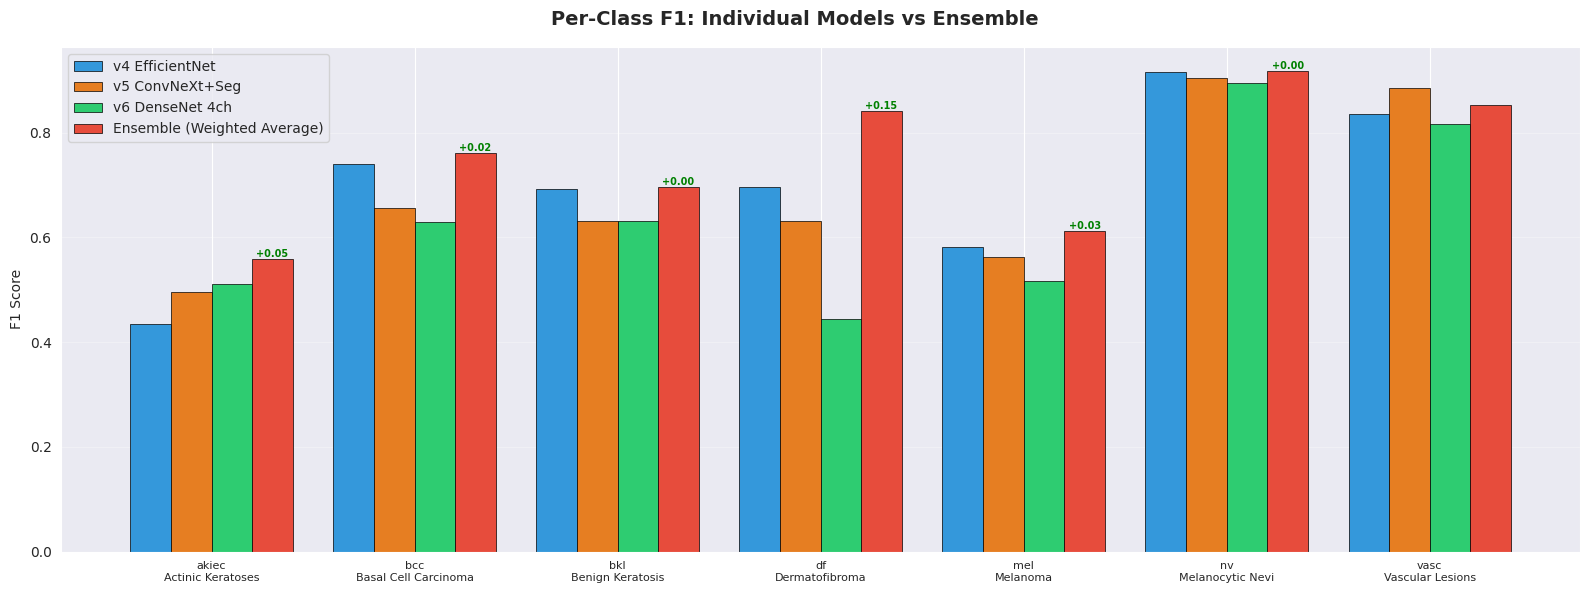

In [ ]:
# Per-class F1 comparison
f1_v4 = f1_score(y_test, np.argmax(preds_test_v4, axis=1), average=None)
f1_v5 = f1_score(y_test, np.argmax(preds_test_v5, axis=1), average=None)
f1_v6 = f1_score(y_test, np.argmax(preds_test_v6, axis=1), average=None)
f1_ens = f1_score(y_test, best_pred_cls, average=None)

x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Per-Class F1: Individual Models vs Ensemble', fontsize=14, fontweight='bold')

ax.bar(x - 1.5*width, f1_v4, width, label='v4 EfficientNet', color='#3498db', edgecolor='black', linewidth=0.5)
ax.bar(x - 0.5*width, f1_v5, width, label='v5 ConvNeXt+Seg', color='#e67e22', edgecolor='black', linewidth=0.5)
ax.bar(x + 0.5*width, f1_v6, width, label='v6 DenseNet 4ch', color='#2ecc71', edgecolor='black', linewidth=0.5)
ax.bar(x + 1.5*width, f1_ens, width, label=f'Ensemble ({best_name})', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{LABEL_NAMES[c]}' for c in classes], fontsize=8)
ax.set_ylabel('F1 Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate improvements
for i in range(len(classes)):
    best_single = max(f1_v4[i], f1_v5[i], f1_v6[i])
    if f1_ens[i] > best_single:
        ax.annotate(f'+{(f1_ens[i]-best_single):.2f}',
                    xy=(x[i] + 1.5*width, f1_ens[i]),
                    fontsize=7, fontweight='bold', color='green', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ensemble_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 9 — Збереження фінальних результатів

In [ ]:
ENSEMBLE_DIR = '/content/drive/MyDrive/HAM10000_ensemble/'
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

# Save best ensemble predictions
np.save(os.path.join(ENSEMBLE_DIR, 'ensemble_preds_test.npy'), best_preds)
np.save(os.path.join(ENSEMBLE_DIR, 'ensemble_pred_classes.npy'), best_pred_cls)
np.save(os.path.join(ENSEMBLE_DIR, 'y_test.npy'), y_test)

# Save meta-learner models
if 'LogReg' in best_name:
    import joblib
    joblib.dump(lr, os.path.join(ENSEMBLE_DIR, 'meta_logreg.pkl'))
if 'XGBoost' in best_name:
    xgb_model.save_model(os.path.join(ENSEMBLE_DIR, 'meta_xgboost.json'))

# Save all results
final_metadata = {
    'ensemble_method': best_name,
    'individual_results': {k: {mk: round(mv, 4) for mk, mv in v.items()} for k, v in results.items()},
    'best_result': {
        'accuracy': float(accuracy_score(y_test, best_pred_cls)),
        'f1_macro': float(f1_score(y_test, best_pred_cls, average='macro')),
        'f1_weighted': float(f1_score(y_test, best_pred_cls, average='weighted')),
        'auc_macro': float(roc_auc_score(np.eye(NUM_CLASSES)[y_test], best_preds, average='macro', multi_class='ovr')),
        'auc_per_class': {cls: float(auc_scores[cls]) for cls in classes},
    },
    'optimal_weights': best_weights.tolist() if 'Weighted' in best_name else None,
    'classes': classes,
    'models': ['v4 EfficientNetV2B2', 'v5 ConvNeXtTiny+Seg', 'v6 DenseNet121 4ch'],
}

with open(os.path.join(ENSEMBLE_DIR, 'ensemble_results.json'), 'w') as f:
    json.dump(final_metadata, f, indent=2, ensure_ascii=False)

print('All ensemble results saved!')
print(json.dumps(final_metadata, indent=2, ensure_ascii=False))

All ensemble results saved!
{
  "ensemble_method": "Weighted Average",
  "individual_results": {
    "v4 EfficientNetV2B2": {
      "acc": 0.8219,
      "f1_macro": 0.6993,
      "f1_weighted": 0.8237,
      "auc": 0.9528
    },
    "v5 ConvNeXtTiny+Seg": {
      "acc": 0.8075,
      "f1_macro": 0.6808,
      "f1_weighted": 0.8057,
      "auc": 0.9484
    },
    "v6 DenseNet121 4ch": {
      "acc": 0.7944,
      "f1_macro": 0.635,
      "f1_weighted": 0.7913,
      "auc": 0.9427
    },
    "Simple Average": {
      "acc": 0.8389,
      "f1_macro": 0.7483,
      "f1_weighted": 0.835,
      "auc": 0.9647
    },
    "Meta: LogReg": {
      "acc": 0.8356,
      "f1_macro": 0.7093,
      "auc": 0.9587
    },
    "Meta: XGBoost": {
      "acc": 0.8193,
      "f1_macro": 0.703,
      "auc": 0.9594
    },
    "Meta: Neural Net": {
      "acc": 0.8258,
      "f1_macro": 0.724,
      "auc": 0.9572
    },
    "Weighted Average": {
      "acc": 0.8396,
      "f1_macro": 0.7484,
      "auc": 0.9647

## Фінальний результат

Ensemble з трьох моделей з різними архітектурами та інпутами дає кращий результат ніж будь-яка модель окремо.

**Чому це працює:**
- Різні архітектури (EfficientNet, ConvNeXt, DenseNet) бачать різні паттерни
- Різні інпути (raw, segmented, 4-channel) дають різну інформацію
- Meta-learner навчається коли довіряти якій моделі